# 1. Import Libraries

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR

from sklearn.decomposition import PCA

from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


#2. Load Dataset

In [4]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

DATASET_PATH = "/content/Folds5x2_pp.xlsx"

df = pd.read_excel(DATASET_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


# 3. Basic Dataset Information

In [5]:
# ============================================================
# 3. BASIC DATASET INFORMATION
# ============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

DATASET INFORMATION

Shape:
(9568, 5)

Columns:
['AT', 'V', 'AP', 'RH', 'PE']

Data Types:
AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB

Statistical Summary:


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


# 4. Clean Column Names

In [6]:
# ============================================================
# 4. CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

print("Columns after cleaning:")
print(df.columns.tolist())

Columns after cleaning:
['AT', 'V', 'AP', 'RH', 'PE']


# 5. Missing Value Analysis

In [7]:
# ============================================================
# 5. MISSING VALUE ANALYSIS
# ============================================================

print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:", missing_values.sum())

if missing_values.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values found. Further preprocessing is required.")

MISSING VALUE ANALYSIS
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

Total missing values: 0
No missing values found.


# 6. Duplicate Analysis

In [8]:
# ============================================================
# 6. DUPLICATE ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Duplicate rows before cleaning:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

print("Dataset shape after duplicate removal:", df.shape)

Duplicate rows before cleaning: 41
Duplicate rows after cleaning: 0
Dataset shape after duplicate removal: (9527, 5)


# 7. Check Invalid / Impossible Values

In [9]:
# ============================================================
# 7. INVALID VALUE CHECK
# ============================================================

print("=" * 60)
print("INVALID VALUE CHECK")
print("=" * 60)

for column in df.columns:
    print(
        f"{column}: "
        f"Minimum = {df[column].min():.2f}, "
        f"Maximum = {df[column].max():.2f}"
    )

INVALID VALUE CHECK
AT: Minimum = 1.81, Maximum = 37.11
V: Minimum = 25.36, Maximum = 81.56
AP: Minimum = 992.89, Maximum = 1033.30
RH: Minimum = 25.56, Maximum = 100.16
PE: Minimum = 420.26, Maximum = 495.76


# 8. Outlier Detection Using IQR

In [10]:
# ============================================================
# 8. OUTLIER DETECTION USING IQR
# ============================================================

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df < lower_bound) |
    (df > upper_bound)
)

print("=" * 60)
print("OUTLIER ANALYSIS")
print("=" * 60)

for column in df.columns:

    count = outlier_mask[column].sum()

    percentage = (
        count / len(df)
    ) * 100

    print(
        f"{column}: "
        f"{count} outliers "
        f"({percentage:.2f}%)"
    )

rows_with_outliers = outlier_mask.any(axis=1).sum()

print(
    f"\nRows containing at least one outlier: "
    f"{rows_with_outliers} / {len(df)}"
)

OUTLIER ANALYSIS
AT: 0 outliers (0.00%)
V: 0 outliers (0.00%)
AP: 91 outliers (0.96%)
RH: 13 outliers (0.14%)
PE: 0 outliers (0.00%)

Rows containing at least one outlier: 104 / 9527


# 9. Boxplots

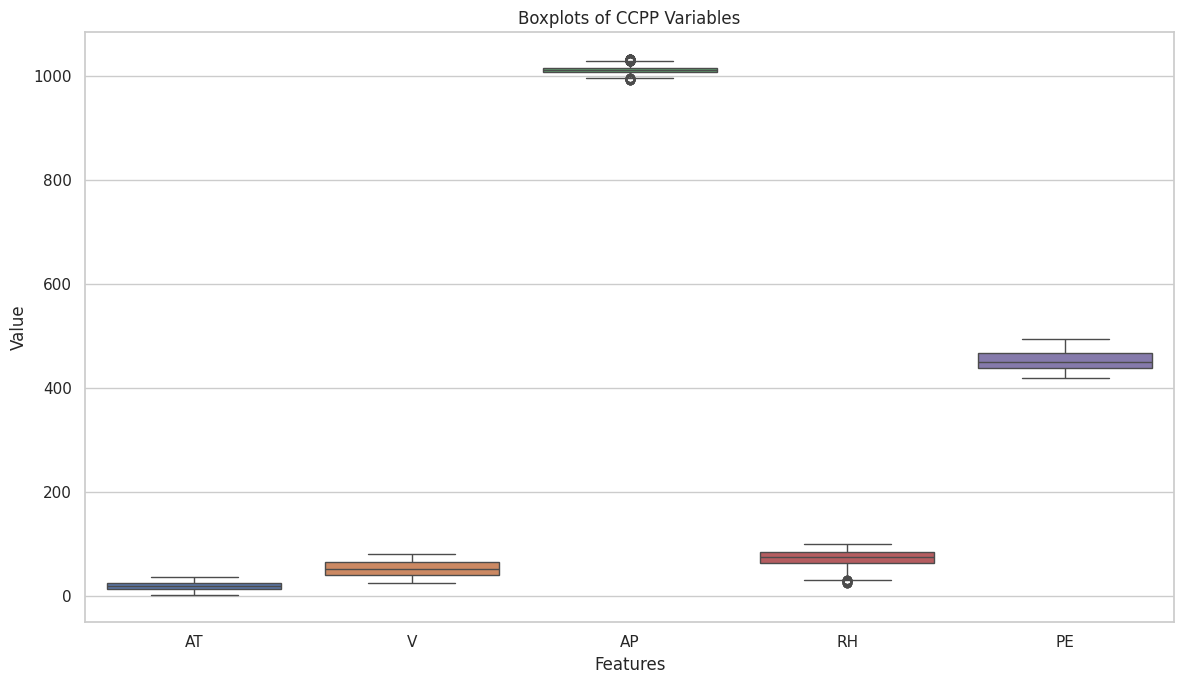

In [11]:
# ============================================================
# 9. BOXPLOTS
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(data=df)

plt.title("Boxplots of CCPP Variables")
plt.xlabel("Features")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

# 10. Feature Distributions

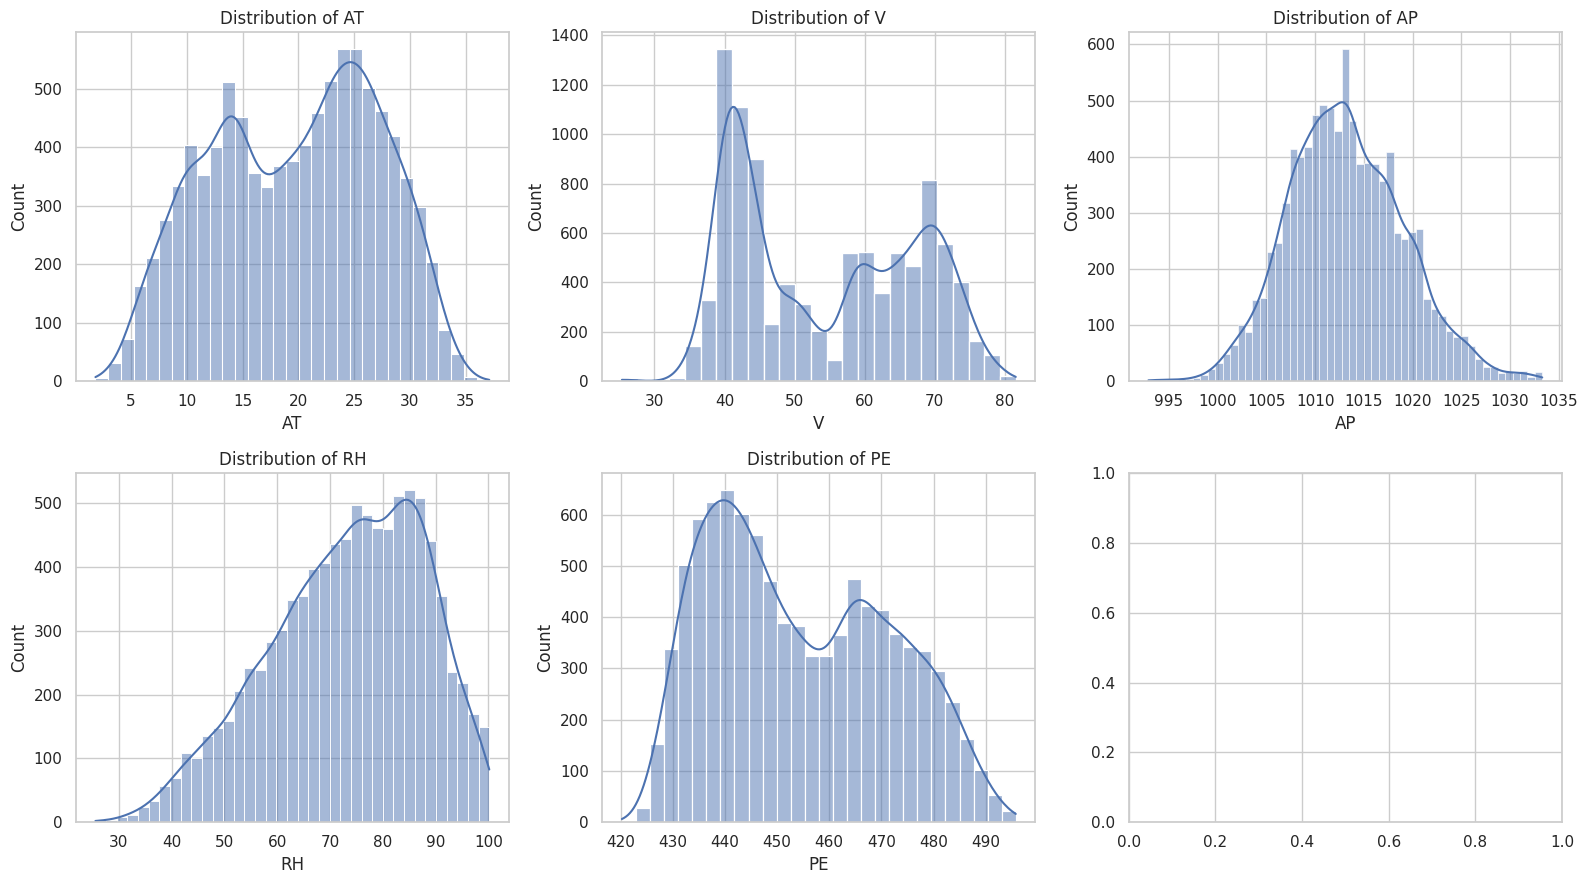

In [12]:
# ============================================================
# 10. FEATURE DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9)
)

for i, column in enumerate(df.columns):

    row = i // 3
    col = i % 3

    sns.histplot(
        df[column],
        kde=True,
        ax=axes[row, col]
    )

    axes[row, col].set_title(
        f"Distribution of {column}"
    )

plt.tight_layout()
plt.show()

# 11. Correlation Analysis

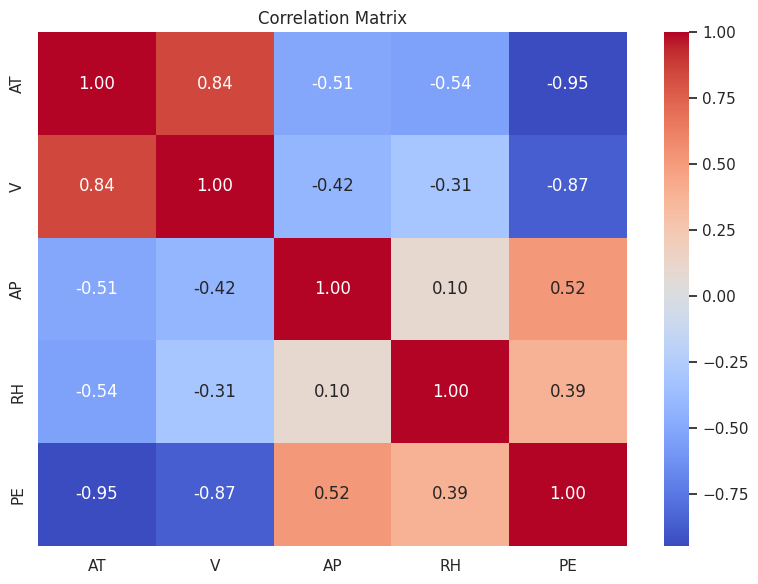

In [13]:
# ============================================================
# 11. CORRELATION MATRIX
# ============================================================

plt.figure(figsize=(8, 6))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# 12. Relationship Between Features and Target

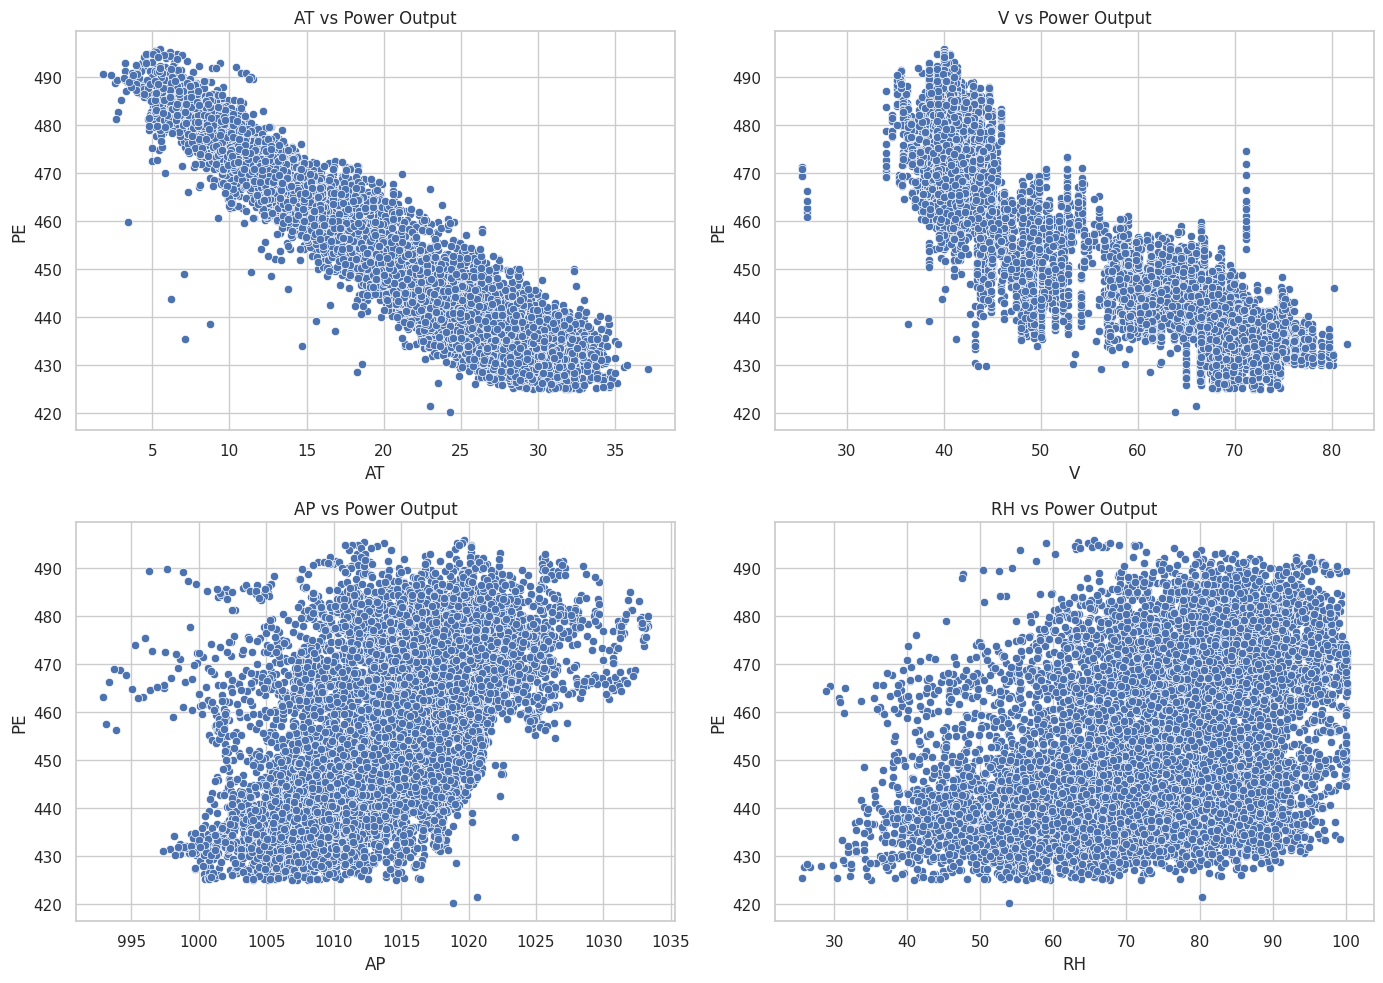

In [14]:
# ============================================================
# 12. FEATURE VS TARGET RELATIONSHIPS
# ============================================================

features = ["AT", "V", "AP", "RH"]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

for i, feature in enumerate(features):

    row = i // 2
    col = i % 2

    sns.scatterplot(
        data=df,
        x=feature,
        y="PE",
        ax=axes[row, col]
    )

    axes[row, col].set_title(
        f"{feature} vs Power Output"
    )

plt.tight_layout()
plt.show()

# 13. Define Features and Target

In [15]:
# ============================================================
# 13. FEATURES AND TARGET
# ============================================================

FEATURES = [
    "AT",
    "V",
    "AP",
    "RH"
]

TARGET = "PE"

X = df[FEATURES]
y = df[TARGET]

print("Features:")
print(FEATURES)

print("\nTarget:")
print(TARGET)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['AT', 'V', 'AP', 'RH']

Target:
PE

X shape: (9527, 4)
y shape: (9527,)


# 14. Train-Test Split

In [16]:
# ============================================================
# 14. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7621
Testing samples: 1906


# 15. Baseline Model

In [17]:
# ============================================================
# 15. BASELINE LINEAR REGRESSION
# ============================================================

baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

baseline_pipeline.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_pipeline.predict(X_test)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("=" * 60)
print("BASELINE MODEL")
print("=" * 60)

print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

BASELINE MODEL
MAE  : 3.6215
RMSE : 4.5875
R²   : 0.9284


# 16. Feature Engineering Investigation

In [18]:
# ============================================================
# 16. FEATURE ENGINEERING
# ============================================================

def create_features(data):

    data = data.copy()

    data["AT_V"] = data["AT"] * data["V"]
    data["AT_squared"] = data["AT"] ** 2
    data["V_squared"] = data["V"] ** 2

    return data


X_train_eng = create_features(X_train)
X_test_eng = create_features(X_test)

print("Original features:")
print(X_train.columns.tolist())

print("\nEngineered features:")
print(X_train_eng.columns.tolist())

Original features:
['AT', 'V', 'AP', 'RH']

Engineered features:
['AT', 'V', 'AP', 'RH', 'AT_V', 'AT_squared', 'V_squared']


# 17. Feature Importance

,Feature,Importance
0,AT,0.900824
1,V,0.062326
2,AP,0.019216
3,RH,0.017634


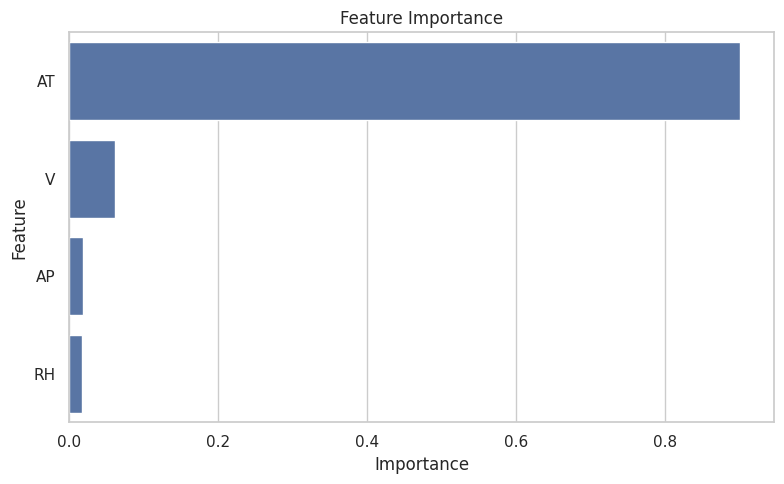

In [19]:
# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================

feature_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

feature_model.fit(
    X_train,
    y_train
)

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": feature_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(importance_df)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.tight_layout()
plt.show()

# 18. PCA Investigation

In [20]:
# ============================================================
# 18. PCA INVESTIGATION
# ============================================================

pca_scaler = StandardScaler()

X_train_scaled = pca_scaler.fit_transform(X_train)

pca = PCA()

pca.fit(X_train_scaled)

explained_variance = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(
    explained_variance
)

print("Individual explained variance:")
print(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_variance)

Individual explained variance:
[0.60760958 0.22877473 0.13756173 0.02605396]

Cumulative explained variance:
[0.60760958 0.83638431 0.97394604 1.        ]


# 19. Build Multiple Models

In [23]:
  # ============================================================
# 19. MODEL COMPARISON
# ============================================================

models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1))
    ]),

    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("model", DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ]),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(
            C=1.0,
            epsilon=0.2
        ))
    ])
}

# 20. Train and Evaluate All Models

In [24]:
# ============================================================
# 20. TRAIN AND EVALUATE MODELS
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[name] = model


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "R2",
    ascending=False
)

display(results_df)

Training Linear Regression...
Training Ridge...
Training Lasso...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVR...


,Model,MAE,RMSE,R2
4,Random Forest,2.417439,3.449400,0.959515
5,Gradient Boosting,3.007175,3.984114,0.945990
6,SVR,3.185655,4.239365,0.938848
3,Decision Tree,3.021628,4.332209,0.936140
1,Ridge,3.621567,4.587460,0.928393
0,Linear Regression,3.621467,4.587499,0.928392
2,Lasso,3.625078,4.590146,0.928309


# 21. Visualize Model Comparison

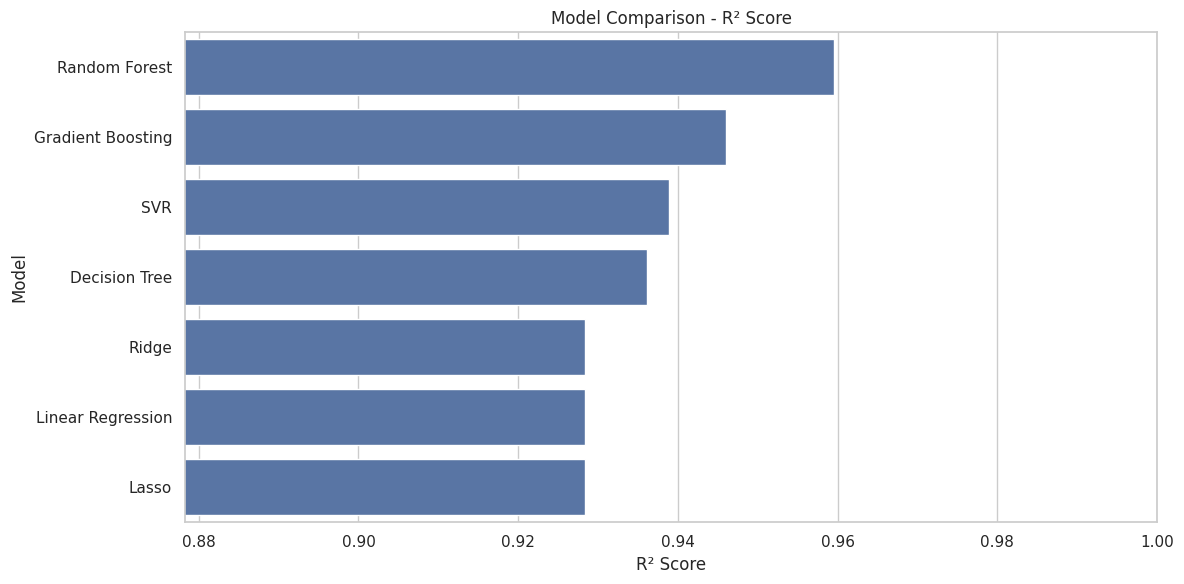

In [25]:
# ============================================================
# 21. MODEL COMPARISON PLOT
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="R2",
    y="Model"
)

plt.title("Model Comparison - R² Score")

plt.xlabel("R² Score")
plt.ylabel("Model")

plt.xlim(
    max(0, results_df["R2"].min() - 0.05),
    1.0
)

plt.tight_layout()
plt.show()

# 22. Cross Validation

In [26]:
# ============================================================
# 22. 5-FOLD CROSS VALIDATION
# ============================================================

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })

cv_results_df = pd.DataFrame(
    cv_results
).sort_values(
    "Mean CV R2",
    ascending=False
)

display(cv_results_df)

,Model,Mean CV R2,Std CV R2
4,Random Forest,0.959847,0.003413
5,Gradient Boosting,0.947961,0.003442
6,SVR,0.939433,0.002792
3,Decision Tree,0.937953,0.005790
1,Ridge,0.928243,0.003910
0,Linear Regression,0.928243,0.003907
2,Lasso,0.928097,0.003999


# 23. Random Forest Hyperparameter Tuning

In [27]:
# ============================================================
# 23. RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {

    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        10,
        15,
        None
    ],

    "model__min_samples_split": [
        2,
        5
    ]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV R²:")
print(grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV R²:
0.957894720283428


# 24. Final Model Evaluation

In [28]:
# ============================================================
# 24. FINAL MODEL EVALUATION
# ============================================================

final_model = grid_search.best_estimator_

final_predictions = final_model.predict(
    X_test
)

final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("=" * 60)
print("FINAL OPTIMIZED RANDOM FOREST")
print("=" * 60)

print(f"MAE  : {final_mae:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"R²   : {final_r2:.4f}")

FINAL OPTIMIZED RANDOM FOREST
MAE  : 2.4150
RMSE : 3.4455
R²   : 0.9596


# 25. Actual vs Predicted

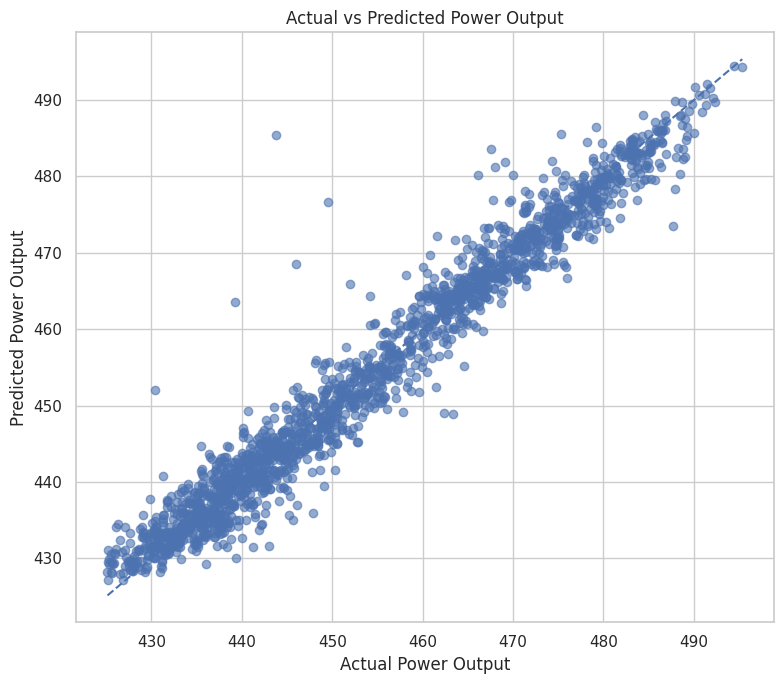

In [29]:
# ============================================================
# 25. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    final_predictions.min()
)

max_value = max(
    y_test.max(),
    final_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")

plt.title(
    "Actual vs Predicted Power Output"
)

plt.tight_layout()
plt.show()

# 26. Residual Analysis

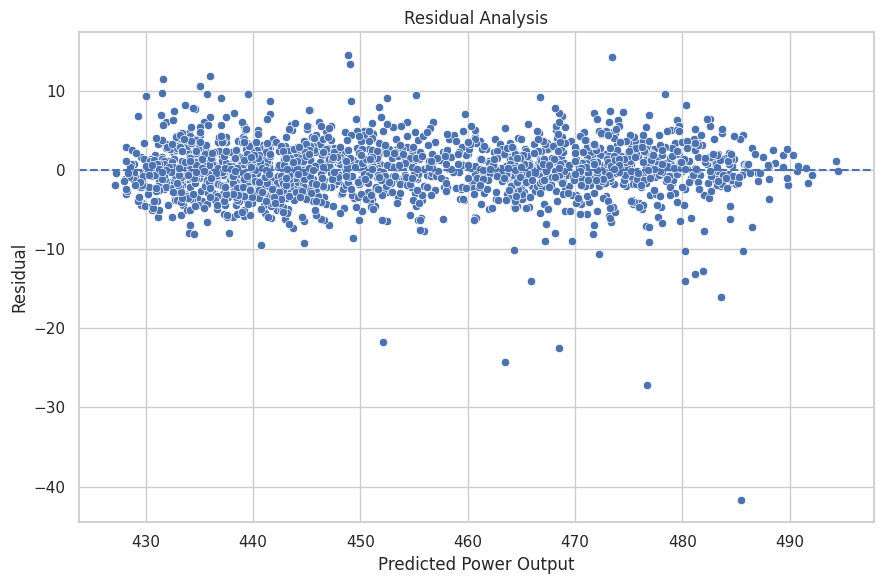

In [30]:
# ============================================================
# 26. RESIDUAL ANALYSIS
# ============================================================

residuals = y_test - final_predictions

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=final_predictions,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Power Output")
plt.ylabel("Residual")

plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

# 28. Final Feature Importance

,Feature,Importance
0,AT,0.900824
1,V,0.062326
2,AP,0.019216
3,RH,0.017634


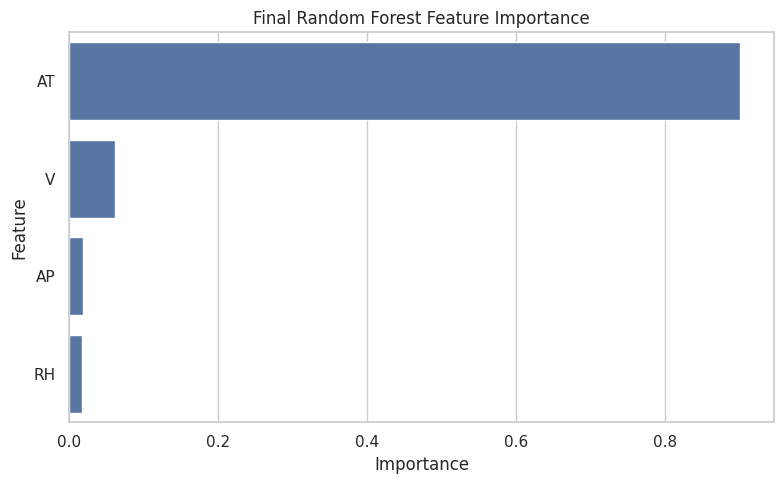

In [31]:
# ============================================================
# 28. FINAL FEATURE IMPORTANCE
# ============================================================

rf_model = final_model.named_steps["model"]

final_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
})

final_importance = final_importance.sort_values(
    "Importance",
    ascending=False
)

display(final_importance)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=final_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Final Random Forest Feature Importance"
)

plt.tight_layout()
plt.show()

# 29. Save Final Model

In [32]:
# ============================================================
# 29. SAVE FINAL MODEL PIPELINE
# ============================================================

os.makedirs(
    "models",
    exist_ok=True
)

MODEL_PATH = (
    "models/"
    "power_output_prediction_model.pkl"
)

joblib.dump(
    final_model,
    MODEL_PATH
)

print("Final model saved successfully:")
print(MODEL_PATH)

Final model saved successfully:
models/power_output_prediction_model.pkl


# 30. Verify Saved Model

In [33]:
# ============================================================
# 30. VERIFY SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    MODEL_PATH
)

verification_inputs = pd.DataFrame(
    [
        [21, 65, 1013, 63],
        [28, 65, 1079, 62],
        [10, 30, 950, 40],
        [35, 80, 1050, 85]
    ],
    columns=FEATURES
)

verification_predictions = loaded_model.predict(
    verification_inputs
)

print("=" * 60)
print("SAVED MODEL VERIFICATION")
print("=" * 60)

for i in range(len(verification_inputs)):

    row = verification_inputs.iloc[i]

    print(
        f"AT={row['AT']}, "
        f"V={row['V']}, "
        f"AP={row['AP']}, "
        f"RH={row['RH']} "
        f"→ PE={verification_predictions[i]:.2f}"
    )

SAVED MODEL VERIFICATION
AT=21, V=65, AP=1013, RH=63 → PE=451.08
AT=28, V=65, AP=1079, RH=62 → PE=440.35
AT=10, V=30, AP=950, RH=40 → PE=474.43
AT=35, V=80, AP=1050, RH=85 → PE=431.24


# 31. Save Model Performance

In [34]:
# ============================================================
# 31. SAVE MODEL PERFORMANCE
# ============================================================

performance = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2"
    ],
    "Value": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

performance.to_csv(
    "models/final_model_performance.csv",
    index=False
)

print("Performance metrics saved.")

Performance metrics saved.


# 32. Generate Business Interpretation

In [35]:
# ============================================================
# 32. BUSINESS INTERPRETATION
# ============================================================

print("=" * 70)
print("BUSINESS INTERPRETATION")
print("=" * 70)

print(f"""
The final Random Forest model achieved:

MAE  = {final_mae:.4f}
RMSE = {final_rmse:.4f}
R²   = {final_r2:.4f}

The model predicts net electrical power output using:
- Ambient Temperature (AT)
- Exhaust Vacuum (V)
- Ambient Pressure (AP)
- Relative Humidity (RH)

The feature importance analysis identifies the operating
conditions that have the greatest influence on power generation.

Business Application:
1. Power plant operators can estimate expected power output
   under current environmental conditions.

2. The prediction can support operational planning and
   performance monitoring.

3. Large differences between predicted and actual output can
   be used as an early indicator of abnormal operating
   conditions.

4. Operators can investigate environmental or equipment
   conditions when the actual output is significantly below
   the expected output.

5. The model can support data-driven decisions for improving
   plant efficiency and reducing unexpected performance loss.
""")

BUSINESS INTERPRETATION

The final Random Forest model achieved:

MAE  = 2.4150
RMSE = 3.4455
R²   = 0.9596

The model predicts net electrical power output using:
- Ambient Temperature (AT)
- Exhaust Vacuum (V)
- Ambient Pressure (AP)
- Relative Humidity (RH)

The feature importance analysis identifies the operating
conditions that have the greatest influence on power generation.

Business Application:
1. Power plant operators can estimate expected power output
   under current environmental conditions.

2. The prediction can support operational planning and
   performance monitoring.

3. Large differences between predicted and actual output can
   be used as an early indicator of abnormal operating
   conditions.

4. Operators can investigate environmental or equipment
   conditions when the actual output is significantly below
   the expected output.

5. The model can support data-driven decisions for improving
   plant efficiency and reducing unexpected performance loss.

